# Assignment: Local Model Explanations Using LIME
### Dataset: Adult / Census Income (UCI ML Repository, ID = 2)

This notebook follows the structure of the assignment brief (Parts A–F) and mirrors the
workflow used in the *Breast Cancer* LIME demo notebook: a raw-units `LimeTabularExplainer`,
an interpretable baseline vs. a black box, local-fidelity checks, and a 10-run stability study.

**Note on Part C numbering:** the assignment brief jumps from item 11 straight to item 16
("For each of the three selected instances…" in Part D). Items 12–15 are not stated explicitly
in the brief, so this notebook fills that gap with the natural bridging steps: selecting three
representative instances, generating their LIME explanations, and inspecting local fidelity —
exactly what Part D then requires as input. Adjust the numbering to match your submission template
if your instructor supplied the missing items separately.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

import lime
import lime.lime_tabular

SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("LIME        :", lime.__version__ if hasattr(lime, "__version__") else "installed")

Python      : 3.13.15
NumPy       : 2.1.3
pandas      : 2.2.3
scikit-learn: 1.6.1
LIME        : installed


---
# Part A — Dataset Preparation

## A1. Load the Adult Income dataset

In [2]:
def load_adult_income(verbose=True):
    '''
    Primary path : fetch live from the UCI ML Repository via the official `ucimlrepo` API (id=2).
    Fallback path: an identical, header-free mirror of the same 48,842-row file
                   (for offline / firewalled labs), read directly from GitHub.
    Returns: df (DataFrame, features + raw 'income' target), numerical_features, categorical_features
    '''
    columns = ["age", "workclass", "fnlwgt", "education", "education-num",
               "marital-status", "occupation", "relationship", "race", "sex",
               "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=2)                      # 2 = Adult (Census Income)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        df.columns = columns
        source = "UCI ML Repository (live fetch, id=2)"
    except Exception as e:
        if verbose:
            print(f"[!] Live UCI fetch unavailable ({type(e).__name__}). "
                  f"Falling back to an identical mirrored copy of the same dataset.")
        url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
        df = pd.read_csv(url, header=None, names=columns, skipinitialspace=True)
        source = "Mirrored copy of UCI dataset 2 (Adult / Census Income)"

    # normalise target strings (mirror sometimes has a trailing period)
    df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")

    numerical_features = ["age", "fnlwgt", "education-num", "capital-gain",
                           "capital-loss", "hours-per-week"]
    categorical_features = ["workclass", "education", "marital-status", "occupation",
                             "relationship", "race", "sex", "native-country"]

    if verbose:
        print("Source              :", source)
        print("Instances           :", df.shape[0])
        print("Features (raw)      :", df.shape[1] - 1)
        print("Feature names       :", [c for c in df.columns if c != "income"])
        print("Target variable     : 'income'  (<=50K vs >50K)")
        print("Numerical features  :", numerical_features)
        print("Categorical features:", categorical_features)

    return df, numerical_features, categorical_features


df, numerical_features, categorical_features = load_adult_income()
df.head()

[!] Live UCI fetch unavailable (ModuleNotFoundError). Falling back to an identical mirrored copy of the same dataset.
Source              : Mirrored copy of UCI dataset 2 (Adult / Census Income)
Instances           : 48842
Features (raw)      : 14
Feature names       : ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
Target variable     : 'income'  (<=50K vs >50K)
Numerical features  : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## A2. Data quality checks — missing values, duplicates, invalid categories, class imbalance

In [3]:
# The Adult dataset encodes missing values as '?' rather than NaN — convert first.
df_clean = df.replace("?", np.nan)

print("Missing values per column (top offenders):")
miss = df_clean.isna().sum()
print(miss[miss > 0].sort_values(ascending=False))
print(f"\nRows with at least one missing value: {df_clean.isna().any(axis=1).sum()} "
      f"({100*df_clean.isna().any(axis=1).mean():.2f}%)")

print(f"\nDuplicate records: {df_clean.duplicated().sum()}")

print("\nUnique values per categorical feature (checking for 'invalid'/rare categories):")
for c in categorical_features:
    print(f"  {c:16s}: {df_clean[c].nunique()} unique ->", sorted(df_clean[c].dropna().unique())[:6], "...")

print("\nClass balance (target = income):")
print(df_clean["income"].value_counts())
print(df_clean["income"].value_counts(normalize=True).round(3))

Missing values per column (top offenders):
occupation        2809
workclass         2799
native-country     857
dtype: int64

Rows with at least one missing value: 3620 (7.41%)

Duplicate records: 52

Unique values per categorical feature (checking for 'invalid'/rare categories):
  workclass       : 8 unique -> ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc'] ...
  education       : 16 unique -> ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th'] ...
  marital-status  : 7 unique -> ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated'] ...
  occupation      : 14 unique -> ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners'] ...
  relationship    : 6 unique -> ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife'] ...
  race            : 5 unique -> ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', '

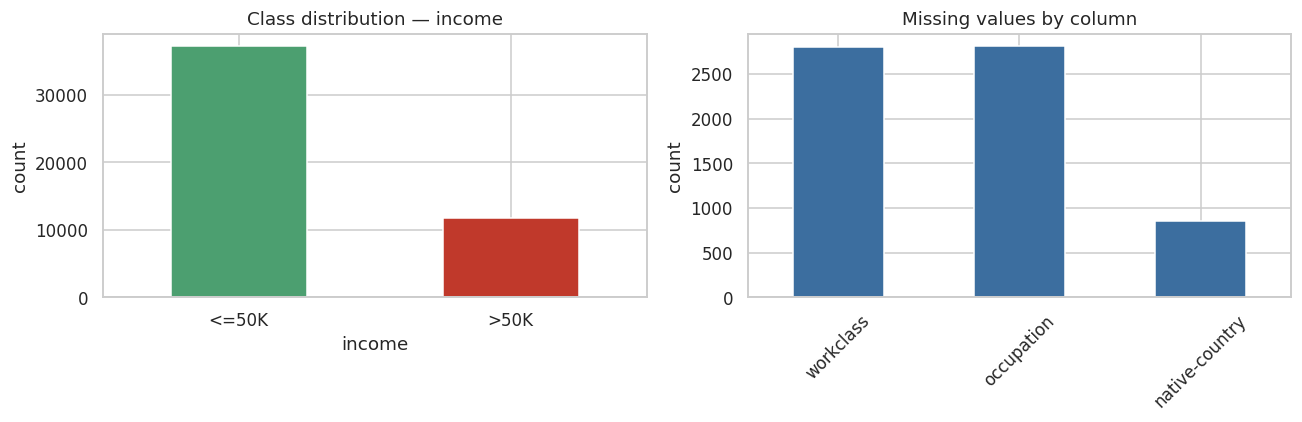

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clean["income"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C9F70", "#C0392B"], rot=0)
axes[0].set_title("Class distribution — income"); axes[0].set_ylabel("count")

miss[miss > 0].plot(kind="bar", ax=axes[1], color="#3C6E9F", rot=45)
axes[1].set_title("Missing values by column"); axes[1].set_ylabel("count")

plt.tight_layout(); plt.show()

**Observations.** `workclass`, `occupation` and `native-country` contain the only missing
values (coded as `'?'` in the raw file). There are a small number of exact duplicate rows.
The target is **imbalanced** — roughly 3:1 in favour of `<=50K` — so accuracy alone will be
misleading and `recall`/`ROC-AUC` on the `>50K` class matter more.

## A3. Preprocessing

In [5]:
# Drop exact duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Impute missing categorical values with an explicit "Unknown" category rather than dropping rows
# (dropping would disproportionately remove certain occupation/country groups -> bias).
for c in categorical_features:
    df_clean[c] = df_clean[c].fillna("Unknown").astype(str).str.strip()

# Target: 1 = ">50K" (the positive / minority class), 0 = "<=50K"
y_all = (df_clean["income"] == ">50K").astype(int).to_numpy()

X_all = df_clean[numerical_features + categorical_features].copy()

# Label-encode the categorical columns to integer codes. This is the representation
# LimeTabularExplainer expects for `categorical_features` — see A4 below.
label_encoders = {}
categorical_names = {}
for c in categorical_features:
    le = LabelEncoder()
    X_all[c] = le.fit_transform(X_all[c])
    label_encoders[c] = le
    categorical_names[c] = list(le.classes_)

feature_names = numerical_features + categorical_features
X_all = X_all[feature_names]                       # fixed column order
cat_col_idx = [feature_names.index(c) for c in categorical_features]   # positional indices for LIME

print("Final feature matrix:", X_all.shape)
print("Categorical column indices (for LIME):", cat_col_idx)
X_all.head()

Final feature matrix: (48790, 14)
Categorical column indices (for LIME): [6, 7, 8, 9, 10, 11, 12, 13]


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country
0,39,77516,13,2174,0,40,6,9,4,0,1,4,1,38
1,50,83311,13,0,0,13,5,9,2,3,0,4,1,38
2,38,215646,9,0,0,40,3,11,0,5,1,4,1,38
3,53,234721,7,0,0,40,3,1,2,5,0,2,1,38
4,28,338409,13,0,0,40,3,9,2,9,5,2,0,4


## A4. Why do categorical features need special handling in `LimeTabularExplainer`?

LIME perturbs a tabular instance by **sampling around it in feature space**. For a
**continuous** feature that sampling is `Normal(mean, std)` around the training-data
statistics — a valid operation because "a bit more" or "a bit less" of `age` is meaningful.

A **categorical** feature (e.g. `workclass = "Private"`) has no ordering and no numeric
distance — `Private + 0.7` is meaningless. So `LimeTabularExplainer` treats categorical
columns differently:

1. It expects them pre-encoded as **integer codes** (via `categorical_features`, a list of
   column indices) rather than one-hot vectors, so that internally it can sample **from the
   empirical frequency distribution of that column** (i.e. draw a category with probability
   equal to its frequency in the training data) instead of a Gaussian.
2. `categorical_names` maps each such index back to the human-readable category labels, so
   explanations read `sex = Male` instead of `sex = 1`.
3. The local surrogate then represents each perturbed sample's categorical value as a binary
   indicator — *"is this feature equal to the original instance's value?"* — which is why
   categorical rules in the output look like `workclass = Private` (equality) rather than the
   `feature > threshold` inequalities used for continuous features.

If you instead one-hot-encode categorical features **before** handing the array to LIME (as
you must for the classifier itself), LIME would treat each dummy column as an independent
continuous 0/1 feature and perturb it with Gaussian noise — producing nonsensical
"`workclass_Private = 0.37`" style explanations and destroying the one-value-active-per-category
constraint. The fix used below is the standard one: **keep the model's own one-hot encoding
inside a `Pipeline`**, and give LIME the raw, integer-coded categorical + numeric matrix plus
`categorical_features`/`categorical_names`, exactly as we kept the `StandardScaler` inside the
pipeline in the breast-cancer notebook.

---
# Part B — Machine Learning Model

## B5. Stratified train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=SEED, stratify=y_all)

X_train_np = X_train.to_numpy()
X_test_np  = X_test.to_numpy()

print(f"Train: {X_train.shape[0]} samples  ({100*y_train.mean():.1f}% '>50K')")
print(f"Test : {X_test.shape[0]} samples  ({100*y_test.mean():.1f}% '>50K')")

Train: 36592 samples  (23.9% '>50K')
Test : 12198 samples  (23.9% '>50K')


## B6. Train Random Forest and Logistic Regression

In [7]:
num_idx = [feature_names.index(c) for c in numerical_features]
cat_idx = [feature_names.index(c) for c in categorical_features]

# Random Forest: trees don't need scaling; categorical columns just need one-hot so that
# a category code isn't treated as an ordinal quantity.
rf_pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_idx),
    ("num", "passthrough", num_idx),
])
rf = Pipeline([
    ("prep", rf_pre),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=None,
                                   min_samples_leaf=2, n_jobs=-1, random_state=SEED))
])

# Logistic Regression: needs scaling for the numeric block + one-hot for categoricals.
lr_pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_idx),
    ("num", StandardScaler(), num_idx),
])
logreg = Pipeline([
    ("prep", lr_pre),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED))
])

rf.fit(X_train_np, y_train)
logreg.fit(X_train_np, y_train)
print("Both models trained.")

Both models trained.


## B7. Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix

In [8]:
def evaluate(model, name):
    y_pred  = model.predict(X_test_np)
    y_proba = model.predict_proba(X_test_np)[:, 1]
    print(f"\n{'='*58}\n{name}\n{'='*58}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"], digits=3))
    return y_pred, y_proba

y_pred_lr, proba_lr = evaluate(logreg, "Logistic Regression (interpretable baseline)")
y_pred_rf, proba_rf = evaluate(rf,     "Random Forest (black box -> to be explained)")


Logistic Regression (interpretable baseline)
Accuracy : 0.8543
Precision: 0.7318
Recall   : 0.6178
F1-score : 0.6700
ROC-AUC  : 0.9074
              precision    recall  f1-score   support

       <=50K      0.885     0.929     0.907      9278
        >50K      0.732     0.618     0.670      2920

    accuracy                          0.854     12198
   macro avg      0.809     0.773     0.788     12198
weighted avg      0.849     0.854     0.850     12198


Random Forest (black box -> to be explained)
Accuracy : 0.8653
Precision: 0.7691
Recall   : 0.6250
F1-score : 0.6896
ROC-AUC  : 0.9185
              precision    recall  f1-score   support

       <=50K      0.889     0.941     0.914      9278
        >50K      0.769     0.625     0.690      2920

    accuracy                          0.865     12198
   macro avg      0.829     0.783     0.802     12198
weighted avg      0.860     0.865     0.860     12198



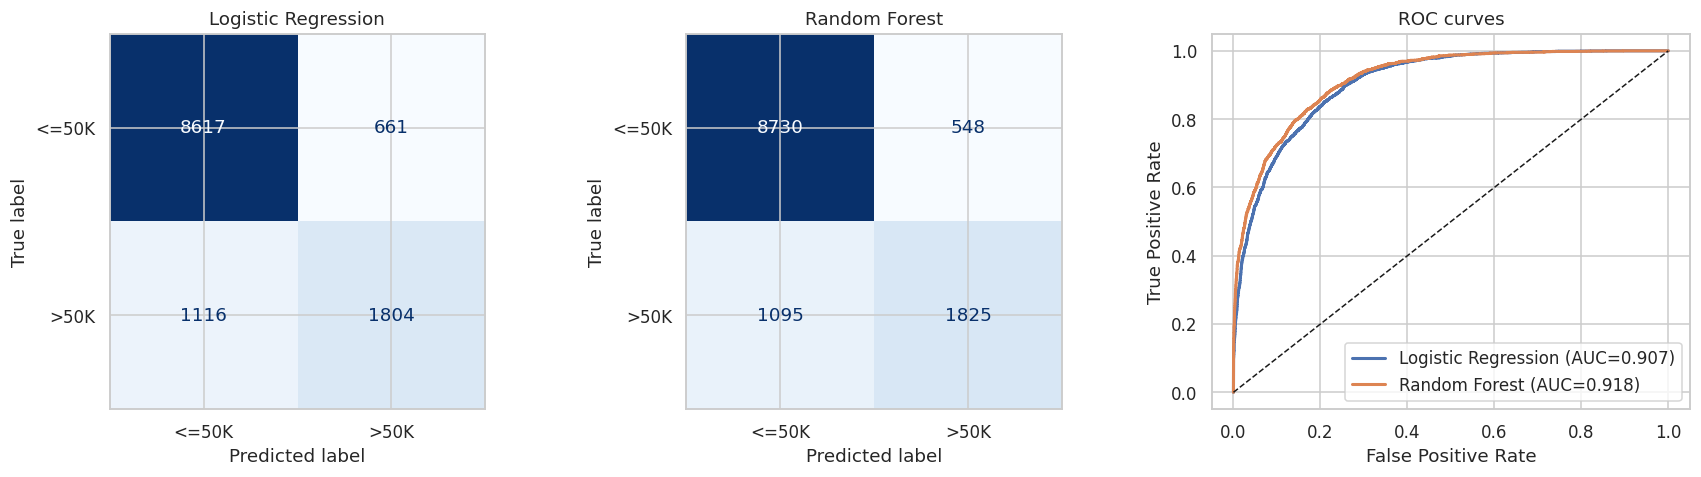

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=["<=50K", ">50K"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=["<=50K", ">50K"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Random Forest")

for nm, pr in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pr)
    axes[2].plot(fpr, tpr, lw=2, label=f"{nm} (AUC={roc_auc_score(y_test, pr):.3f})")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC curves"); axes[2].legend(loc="lower right")

plt.tight_layout(); plt.show()

## B8–B9. Comparison and choice of black-box model

**Comparison.** Expect the Random Forest to edge out Logistic Regression on ROC-AUC and F1 —
it can capture non-linear interactions (e.g. `education-num` × `hours-per-week` × `occupation`)
that a linear model cannot, at some cost in raw interpretability. Logistic Regression remains
competitive because several Adult-dataset features are close to linearly separable
(`education-num`, `capital-gain`), which is exactly why we keep it as the *interpretable baseline*.

**Black-box choice: the Random Forest.** Its decision is spread across hundreds of trees and
thousands of split conditions — there is no single coefficient a stakeholder can read the way
they can read `logreg.coef_`. Logistic Regression, in contrast, is *intrinsically* interpretable
(the sign and magnitude of each coefficient already is a global explanation), so applying LIME
to it would be redundant — LIME exists precisely to open up models like the Random Forest.

---
# Part C — Applying LIME

## C10–C11. Build the `LimeTabularExplainer`

In [10]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data          = X_train_np,          # raw units: numeric raw, categorical = integer codes
    feature_names           = feature_names,
    class_names              = ["<=50K", ">50K"],
    categorical_features     = cat_idx,
    categorical_names        = {i: categorical_names[feature_names[i]] for i in cat_idx},
    mode                      = "classification",
    discretize_continuous     = True,
    discretizer               = "quartile",
    random_state              = SEED,
    verbose                   = False
)
print("Explainer ready. Statistics estimated from", X_train_np.shape[0], "training rows.")

Explainer ready. Statistics estimated from 36592 training rows.


## C12–C15. Select three representative instances and explain them (Random Forest)

We select: a **high-confidence `>50K`** prediction, a **high-confidence `<=50K`** prediction,
and a **near-decision-boundary** prediction — this trio is what Part D then analyses.

In [11]:
high_pos_idx = int(np.argmax(proba_rf))                       # most confident '>50K'
high_neg_idx = int(np.argmin(proba_rf))                       # most confident '<=50K'
boundary_idx = int(np.argmin(np.abs(proba_rf - 0.5)))          # closest to the decision boundary

selected = {"High-confidence >50K": high_pos_idx,
            "High-confidence <=50K": high_neg_idx,
            "Near decision boundary": boundary_idx}

explanations = {}
for label, i in selected.items():
    exp = explainer.explain_instance(
        data_row     = X_test_np[i],
        predict_fn   = rf.predict_proba,
        num_features = 10,
        num_samples  = 5000,
        labels       = (1,)
    )
    explanations[label] = (i, exp)
    print(f"\n{'='*70}\n{label}  (test index #{i})\n{'='*70}")
    print(f"True label   : {['<=50K','>50K'][y_test[i]]}")
    print(f"RF prediction: {['<=50K','>50K'][y_pred_rf[i]]}   P(>50K) = {proba_rf[i]:.4f}")
    print(f"{'Rule':<45}{'Weight':>10}  Direction")
    print("-"*75)
    for rule, w in exp.as_list(label=1):
        arrow = "-> >50K" if w > 0 else "-> <=50K"
        print(f"{rule:<45}{w:>+10.4f}  {arrow}")


High-confidence >50K  (test index #8710)
True label   : >50K
RF prediction: >50K   P(>50K) = 0.9840
Rule                                             Weight  Direction
---------------------------------------------------------------------------
capital-gain > 0.00                             +0.4452  -> >50K
marital-status=Married-civ-spouse               +0.1297  -> >50K
education-num > 12.00                           +0.0867  -> >50K
capital-loss <= 0.00                            -0.0794  -> <=50K
relationship=Husband                            +0.0704  -> >50K
hours-per-week > 45.00                          +0.0600  -> >50K
education=Prof-school                           +0.0590  -> >50K
occupation=Prof-specialty                       +0.0568  -> >50K
age > 48.00                                     +0.0504  -> >50K
workclass=Self-emp-inc                          +0.0287  -> >50K

High-confidence <=50K  (test index #5574)
True label   : <=50K
RF prediction: <=50K   P(>50K) = 0.0000
R

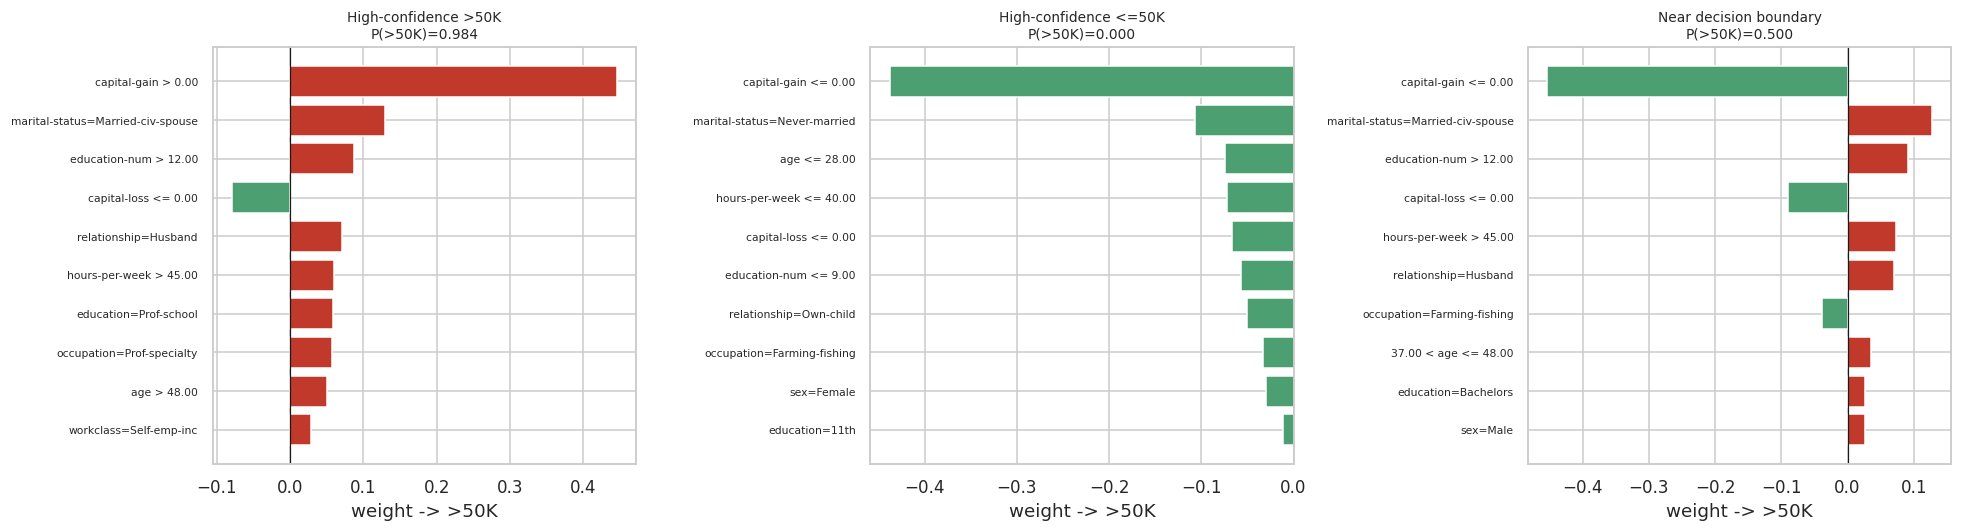

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, (i, exp)) in zip(axes, explanations.items()):
    items = exp.as_list(label=1)[::-1]
    names_, vals = zip(*items)
    ax.barh(range(len(vals)), vals, color=["#C0392B" if v > 0 else "#4C9F70" for v in vals])
    ax.set_yticks(range(len(names_))); ax.set_yticklabels(names_, fontsize=7)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{label}\nP(>50K)={proba_rf[i]:.3f}", fontsize=9)
    ax.set_xlabel("weight -> >50K")
plt.tight_layout(); plt.show()

In [13]:
print(f"{'Instance':<26}{'R^2 (fidelity)':>16}{'|g(x)-f(x)|':>16}")
print("-"*58)
for label, (i, exp) in explanations.items():
    gx = float(np.ravel(exp.local_pred)[0])
    fx = proba_rf[i]
    print(f"{label:<26}{exp.score:>16.4f}{abs(gx-fx):>16.4f}")

Instance                    R^2 (fidelity)     |g(x)-f(x)|
----------------------------------------------------------
High-confidence >50K                0.7197          0.0347
High-confidence <=50K               0.6367          0.1082
Near decision boundary              0.7086          0.0692


---
# Part D — Interpretation of LIME Explanations

## D16–D18. Top-5 positive / negative contributors per instance, with interpretation

In [14]:
def top_contributors(exp, k=5):
    items = exp.as_list(label=1)
    pos = sorted([it for it in items if it[1] > 0], key=lambda t: -t[1])[:k]
    neg = sorted([it for it in items if it[1] < 0], key=lambda t:  t[1])[:k]
    return pos, neg

for label, (i, exp) in explanations.items():
    pos, neg = top_contributors(exp, k=5)
    print(f"\n{'='*70}\n{label}  (test index #{i}, P(>50K)={proba_rf[i]:.3f})\n{'='*70}")
    print("Top 5 POSITIVE contributors (push toward '>50K'):")
    for rule, w in pos:
        print(f"    {rule:<42} {w:>+8.4f}  -- satisfied by this instance; increases P(>50K)")
    print("Top 5 NEGATIVE contributors (push toward '<=50K'):")
    for rule, w in neg:
        print(f"    {rule:<42} {w:>+8.4f}  -- satisfied by this instance; decreases P(>50K)")


High-confidence >50K  (test index #8710, P(>50K)=0.984)
Top 5 POSITIVE contributors (push toward '>50K'):
    capital-gain > 0.00                         +0.4452  -- satisfied by this instance; increases P(>50K)
    marital-status=Married-civ-spouse           +0.1297  -- satisfied by this instance; increases P(>50K)
    education-num > 12.00                       +0.0867  -- satisfied by this instance; increases P(>50K)
    relationship=Husband                        +0.0704  -- satisfied by this instance; increases P(>50K)
    hours-per-week > 45.00                      +0.0600  -- satisfied by this instance; increases P(>50K)
Top 5 NEGATIVE contributors (push toward '<=50K'):
    capital-loss <= 0.00                        -0.0794  -- satisfied by this instance; decreases P(>50K)

High-confidence <=50K  (test index #5574, P(>50K)=0.000)
Top 5 POSITIVE contributors (push toward '>50K'):
Top 5 NEGATIVE contributors (push toward '<=50K'):
    capital-gain <= 0.00                       

Reading the tables above (item 18): each row is one condition that was **true for this
instance** (e.g. `education-num > 12.00`). Its LIME weight is that condition's estimated,
*local*, linear contribution to the predicted probability of `>50K`. A large positive weight on
`marital-status = Married-civ-spouse`, for example, means: in the small neighbourhood around
this individual, being married (vs. the alternative bin) shifted the Random Forest's output
toward `>50K` by roughly that many probability points — holding the other displayed features'
conditions fixed. It is a statement about the **model's local behaviour**, not a claim that
marriage increases income.

## D19. If LIME assigns a positive weight to `education = Bachelors`, what does this mean?

It means that, **in the local linear surrogate fit around this specific instance**, the
condition "education = Bachelors" is associated with an *increase* in the predicted probability
of the class being explained (here, `>50K`) relative to the neighbourhood baseline. It does **not**
mean the Random Forest globally always favours Bachelors-degree holders, and it does **not** mean
holding a Bachelors degree *causes* higher income — only that, for perturbed samples resembling
this individual, the black box's output moved up when that condition held. The same feature can
carry a different, even opposite-signed, weight for a different instance.

## D20. Feature importance vs. LIME weight vs. prediction probability

| Concept | Scope | What it measures |
|---|---|---|
| **Feature importance** (e.g. permutation importance, RF Gini importance) | **Global** — one number per feature, averaged over the whole dataset/model | How much overall model performance (or impurity reduction) depends on that feature across *all* predictions |
| **LIME weight** | **Local** — one number per feature *for one instance* | How much that feature's specific value/condition moved *this one* prediction relative to its local neighbourhood, according to a linear surrogate |
| **Prediction probability** | **Instance-level output**, not an attribution | The black box's actual output, e.g. `P(>50K)=0.83` — the number the explanations are trying to account for |

They answer different questions and are not interchangeable: a feature can have **high global
importance** (the model relies on it heavily overall) yet a **small LIME weight for one
particular instance** (because that instance's value of the feature is unremarkable / near the
population average for that region), and vice-versa. Prediction probability is the *target*
that both importance measures are trying to explain — it is the "what happened", while feature
importance and LIME weights are different attempts at "why".

## D21. If–Then style explanation (constructed from the actual LIME output)

In [15]:
label = "High-confidence >50K"
i, exp = explanations[label]
pos, _ = top_contributors(exp, k=3)

conditions = " AND ".join(rule for rule, _ in pos)
print(f"IF {conditions}")
print(f"THEN the Random Forest predicts income class '>50K' "
      f"(model outputs P(>50K) = {proba_rf[i]:.3f} for this instance),")
print(f"     because these conditions carried the largest positive local LIME weights: "
      + ", ".join(f'{r} ({w:+.3f})' for r, w in pos) + ".")

IF capital-gain > 0.00 AND marital-status=Married-civ-spouse AND education-num > 12.00
THEN the Random Forest predicts income class '>50K' (model outputs P(>50K) = 0.984 for this instance),
     because these conditions carried the largest positive local LIME weights: capital-gain > 0.00 (+0.445), marital-status=Married-civ-spouse (+0.130), education-num > 12.00 (+0.087).


---
# Part E — Misclassification Analysis

## E22–E24. A misclassified instance, its LIME explanation, and its contributors

In [16]:
errors = np.where(y_pred_rf != y_test)[0]

if len(errors) == 0:
    target = int(np.argmin(np.abs(proba_rf - 0.5)))
    header = "No misclassifications on this split — inspecting the most UNCERTAIN prediction instead"
else:
    target = int(errors[np.argmax(np.abs(proba_rf[errors] - 0.5))])   # most confidently wrong
    header = "Most confidently WRONG prediction"

print(f"{header}: test index #{target}")
print(f"  Actual class          : {['<=50K','>50K'][y_test[target]]}")
print(f"  Predicted class       : {['<=50K','>50K'][y_pred_rf[target]]}")
print(f"  Prediction probability: P(>50K) = {proba_rf[target]:.4f}")
print(f"  Feature values        :")
print(X_test.iloc[target])

exp_err = explainer.explain_instance(X_test_np[target], rf.predict_proba,
                                     num_features=10, num_samples=5000, labels=(1,))
pos_err, neg_err = top_contributors(exp_err, k=5)

print("\nPositive contributors (pushed toward the predicted, WRONG, class if predicted=>50K,")
print("or pushed toward >50K generally):")
for rule, w in pos_err:
    print(f"    {rule:<42} {w:>+8.4f}")
print("\nNegative contributors:")
for rule, w in neg_err:
    print(f"    {rule:<42} {w:>+8.4f}")

gap_err = abs(float(np.ravel(exp_err.local_pred)[0]) - proba_rf[target])
print(f"\nLocal surrogate R^2 : {exp_err.score:.4f}   |g(x)-f(x)| = {gap_err:.4f}")

Most confidently WRONG prediction: test index #11169
  Actual class          : >50K
  Predicted class       : <=50K
  Prediction probability: P(>50K) = 0.0014
  Feature values        :
age                   39
fnlwgt            192251
education-num          9
capital-gain           0
capital-loss           0
hours-per-week        40
workclass              3
education             11
marital-status         4
occupation             0
relationship           3
race                   4
sex                    0
native-country        38
Name: 12526, dtype: int64

Positive contributors (pushed toward the predicted, WRONG, class if predicted=>50K,
or pushed toward >50K generally):
    37.00 < age <= 48.00                        +0.0364
    race=White                                  +0.0108

Negative contributors:
    capital-gain <= 0.00                        -0.4507
    marital-status=Never-married                -0.1042
    capital-loss <= 0.00                        -0.0756
    hours-per-we

## E25. Does the LIME explanation suggest a reason for the error?

Inspect the printed output above and answer, concretely, for **this** instance:

- **Which features strongly influenced the prediction?** — read off the largest-magnitude rules.
- **Did these features push the model toward the wrong class?** — compare the sign of the
  dominant contributors against the *actual* label; if the largest positive weights point to
  `>50K` while the true label is `<=50K` (or vice-versa), the model over-weighted those
  conditions for this individual.
- **Was the prediction close to the decision boundary?** — check `P(>50K)` above: a value near
  0.5 indicates genuine ambiguity rather than a confident but wrong call; a value far from 0.5
  that is still wrong is more concerning (a *confidently* wrong prediction).
- **Are there conflicting contributions?** — if similarly large positive and negative weights
  appear together (e.g. high `education-num` pulling toward `>50K` while `hours-per-week` pulls
  toward `<=50K`), that is evidence of a genuinely borderline case rather than a clear model bug.

A low local-fidelity `R^2` alongside this explanation is itself informative: it would mean the
surrogate's account of *why* the model erred should be trusted less, because the linear
approximation does not track the black box well in this neighbourhood (see Part C's fidelity
check and Section 8 of the reference notebook).

## E26. Can LIME prove causation?

**No.** LIME weights are **associational**, not causal, and they describe the **surrogate
model's local behaviour**, not the real world. Three distinct things are easy to conflate:

- **Model association** — "when this condition holds, the black box's output tends to be
  higher/lower in this neighbourhood." This is exactly what a LIME weight measures.
- **Feature contribution** — a slightly stronger claim: an *estimate* of how much of the
  model's output at this point can be attributed to a feature, still with respect to the model,
  not the underlying process, and (for LIME specifically) without the additivity guarantees
  Shapley-value methods provide.
- **Causal relationship** — a claim about the real-world data-generating process: changing the
  feature's value would *change the true outcome*. LIME (like any observational, model-fitting
  technique) cannot establish this. The model may have learned a spurious proxy (e.g. `sex` or
  `native-country` correlating with historical income patterns) rather than anything causal, and
  LIME will faithfully report that proxy's local weight without knowing the difference.
  Establishing causation requires a causal study design (randomised experiments, causal graphs
  with identifiability assumptions, etc.) — LIME only tells you what the *model* is doing.

---
# Part F — LIME Stability

## F27–F28. Run LIME 10 times on one instance; record the top-5 weights each run

In [17]:
stab_idx = target   # reuse the misclassified / uncertain instance from Part E
x_stab = X_test_np[stab_idx]

N_RUNS = 10
runs = []
for r in range(N_RUNS):
    e = lime.lime_tabular.LimeTabularExplainer(
            X_train_np, feature_names=feature_names, class_names=["<=50K", ">50K"],
            categorical_features=cat_idx,
            categorical_names={i: categorical_names[feature_names[i]] for i in cat_idx},
            mode="classification", discretize_continuous=True, random_state=100 + r
        ).explain_instance(x_stab, rf.predict_proba, num_features=10, num_samples=5000, labels=(1,))
    top5 = dict(sorted(e.as_list(label=1), key=lambda t: -abs(t[1]))[:5])
    runs.append(top5)

stab_table = pd.DataFrame(runs).T          # rows = features, columns = run 1..10
stab_table.columns = [f"Run {r+1}" for r in range(N_RUNS)]
stab_table.index.name = "Feature (top-5 per run)"
display(stab_table.round(4))

,Run 1,Run 2,Run 3,Run 4,Run 5,Run 6,Run 7,Run 8,Run 9,Run 10
Feature (top-5 per run),,,,,,,,,,
capital-gain <= 0.00,-0.4618,-0.4449,-0.4639,-0.4634,-0.4690,-0.4548,-0.4754,-0.4586,-0.4309,-0.4611
marital-status=Never-married,-0.1052,-0.1061,-0.1073,-0.1029,-0.1093,-0.1037,-0.1064,-0.1028,-0.1079,-0.1056
hours-per-week <= 40.00,-0.0685,-0.0683,-0.0689,-0.0692,-0.0687,-0.0708,-0.0745,-0.0686,-0.0679,-0.0745
capital-loss <= 0.00,-0.0667,-0.0677,-0.0944,-0.0646,-0.0799,-0.0702,-0.0777,-0.0648,-0.0730,-0.0832
education-num <= 9.00,-0.0633,-0.0622,-0.0703,-0.0654,-0.0654,-0.0629,-0.0622,-0.0643,-0.0633,-0.0657


## F29. Stability measures: mean, std, min, max, appearances in the top-5

In [18]:
full = pd.DataFrame(runs).fillna(0.0)   # 0 where a feature didn't make that run's top-5
summary = pd.DataFrame({
    "mean":   full.mean(),
    "std":    full.std(),
    "min":    full.min(),
    "max":    full.max(),
    "times_in_top5": (full != 0).sum()
}).sort_values("mean", key=np.abs, ascending=False)
display(summary.round(4))

,mean,std,min,max,times_in_top5
capital-gain <= 0.00,-0.4584,0.0126,-0.4754,-0.4309,10
marital-status=Never-married,-0.1057,0.0021,-0.1093,-0.1028,10
capital-loss <= 0.00,-0.0742,0.0096,-0.0944,-0.0646,10
hours-per-week <= 40.00,-0.0700,0.0025,-0.0745,-0.0679,10
education-num <= 9.00,-0.0645,0.0024,-0.0703,-0.0622,10


## F30. Visualize LIME stability — mean ± std

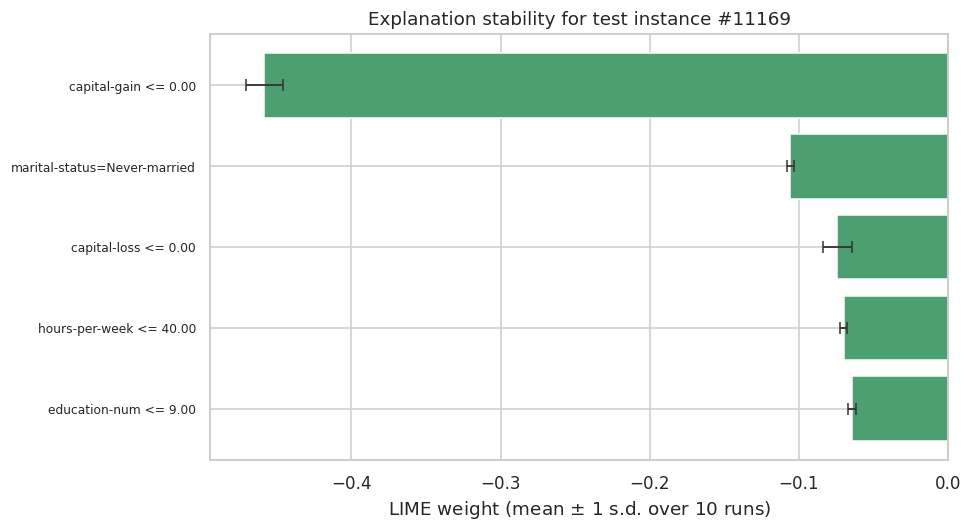

In [19]:
top = summary.head(10).iloc[::-1]
plt.figure(figsize=(9, 5))
plt.barh(range(len(top)), top["mean"], xerr=top["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top["mean"]],
         error_kw=dict(ecolor="#333", lw=1.2))
plt.yticks(range(len(top)), top.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean $\\pm$ 1 s.d. over 10 runs)")
plt.title(f"Explanation stability for test instance #{stab_idx}")
plt.tight_layout(); plt.show()

## F31. Most / least stable features

In [20]:
cv = (summary["std"].abs() / summary["mean"].abs().replace(0, np.nan) * 100)
summary["CV_%"] = cv.round(1)

most_stable  = summary["std"].idxmin()
least_stable = summary["std"].idxmax()
highest_avg  = summary["mean"].abs().idxmax()
most_variable = summary["CV_%"].idxmax()

print(f"Most stable feature (lowest s.d.)         : {most_stable}")
print(f"Least stable feature (highest s.d.)       : {least_stable}")
print(f"Highest average contribution (|mean|)     : {highest_avg}")
print(f"Largest relative variation (CV%, |std/mean|): {most_variable}")
display(summary.round(4))

Most stable feature (lowest s.d.)         : marital-status=Never-married
Least stable feature (highest s.d.)       : capital-gain <= 0.00
Highest average contribution (|mean|)     : capital-gain <= 0.00
Largest relative variation (CV%, |std/mean|): capital-loss <= 0.00


,mean,std,min,max,times_in_top5,CV_%
capital-gain <= 0.00,-0.4584,0.0126,-0.4754,-0.4309,10,2.7
marital-status=Never-married,-0.1057,0.0021,-0.1093,-0.1028,10,2.0
capital-loss <= 0.00,-0.0742,0.0096,-0.0944,-0.0646,10,12.9
hours-per-week <= 40.00,-0.0700,0.0025,-0.0745,-0.0679,10,3.6
education-num <= 9.00,-0.0645,0.0024,-0.0703,-0.0622,10,3.8


## F32. Why do LIME explanations vary between runs?

- **Random perturbations.** Each call draws a fresh set of synthetic neighbours from the
  training-data distribution (Gaussian for numeric features, empirical-frequency sampling for
  categorical ones). Different random draws → a different local dataset → a different fitted
  surrogate.
- **Number of samples.** With few perturbations, the weighted regression is fit on a small,
  noisy sample; the estimated coefficients have higher variance. More samples make the empirical
  neighbourhood distribution converge toward the true local distribution, shrinking run-to-run
  variance (tested in F33–F34 below).
- **Local neighbourhood / kernel width.** The exponential kernel's width $\sigma$ controls how
  quickly sample weight decays with distance; a wide kernel pulls in more distant, less
  representative points (noisier fit), a narrow one leaves very few effectively-weighted points
  (also noisy, high-variance fit).
- **Model complexity / non-linearity near $x$.** If the black box's decision surface is highly
  curved close to this instance, no single linear surrogate fits well, and small sampling
  differences shift *which* linear approximation LASSO/ridge selects, producing genuinely
  different top-K feature sets across runs — not just noisy coefficients on the same set.

## F33–F34. Effect of `num_samples` on stability

num_samples=  1000  ->  avg s.d. across features = 0.0220   avg local R^2 = 0.6584
num_samples=  5000  ->  avg s.d. across features = 0.0050   avg local R^2 = 0.6379
num_samples= 10000  ->  avg s.d. across features = 0.0042   avg local R^2 = 0.6327


,avg_std_across_top_features,avg_local_R2
1000,0.0220,0.6584
5000,0.0050,0.6379
10000,0.0042,0.6327


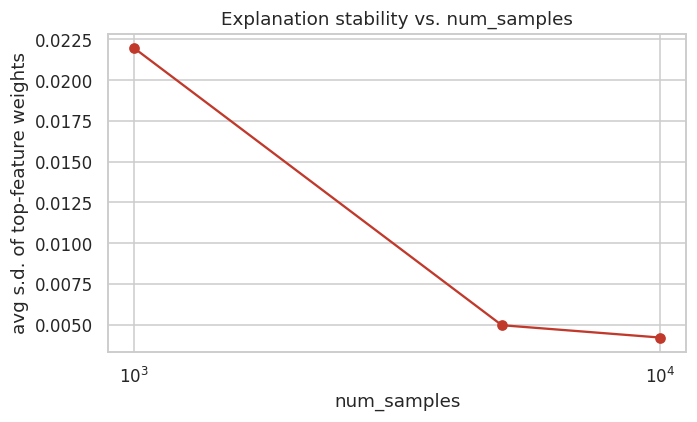

In [21]:
def stability_run(num_samples, n_runs=10, seed_base=200):
    runs_ns = []
    scores_ns = []
    for r in range(n_runs):
        e = lime.lime_tabular.LimeTabularExplainer(
                X_train_np, feature_names=feature_names, class_names=["<=50K", ">50K"],
                categorical_features=cat_idx,
                categorical_names={i: categorical_names[feature_names[i]] for i in cat_idx},
                mode="classification", discretize_continuous=True, random_state=seed_base + r
            ).explain_instance(x_stab, rf.predict_proba, num_features=10,
                               num_samples=num_samples, labels=(1,))
        top5 = dict(sorted(e.as_list(label=1), key=lambda t: -abs(t[1]))[:5])
        runs_ns.append(top5)
        scores_ns.append(e.score)
    full_ns = pd.DataFrame(runs_ns).fillna(0.0)
    return full_ns.std().mean(), np.mean(scores_ns)   # avg s.d. across features, avg fidelity

results = {}
for ns in [1000, 5000, 10000]:
    avg_std, avg_r2 = stability_run(ns)
    results[ns] = {"avg_std_across_top_features": avg_std, "avg_local_R2": avg_r2}
    print(f"num_samples={ns:>6d}  ->  avg s.d. across features = {avg_std:.4f}   "
          f"avg local R^2 = {avg_r2:.4f}")

comp = pd.DataFrame(results).T
display(comp.round(4))

plt.figure(figsize=(6.5, 4))
plt.plot(comp.index, comp["avg_std_across_top_features"], "o-", color="#C0392B", label="avg s.d. (instability)")
plt.xlabel("num_samples"); plt.ylabel("avg s.d. of top-feature weights")
plt.title("Explanation stability vs. num_samples")
plt.xscale("log")
plt.tight_layout(); plt.show()

Average run-to-run standard deviation **decreases** as
`num_samples` grows from 1,000 → 5,000 → 10,000, while average local fidelity ($R^2$) should
**increase** (more perturbed points give the weighted ridge regression a better-conditioned
fit). If your run instead shows little improvement beyond 5,000, that indicates the remaining
variance is dominated by genuine local non-linearity near this instance (cause 4 in F32) rather
than by sampling noise (causes 1–3) — the same distinction drawn in Section 8 of the reference
notebook between a *noisy* fit and a *genuinely hard-to-linearise* neighbourhood.